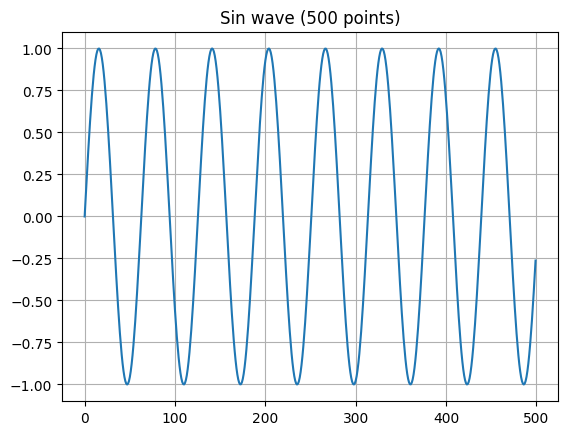

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

t = np.linspace(0, 50, 500)
data = np.sin(t)

plt.plot(data)
plt.title("Sin wave (500 points)")
plt.grid()
plt.show()

In [2]:
def create_sequences(data, seq_length):

    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    X = np.array(X).reshape(-1, seq_length, 1)
    y = np.array(y).reshape(-1, 1)

    return X, y

In [3]:
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super().__init__()

        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

model = RNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

print(model)

RNN(
  (rnn): RNN(1, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=1, bias=True)
)


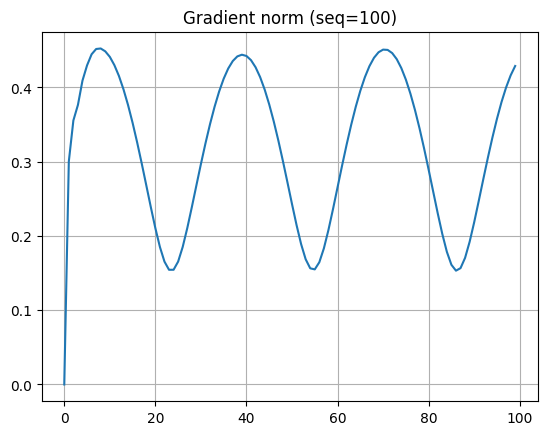

In [4]:
seq_length = 100
X, y = create_sequences(data, seq_length)

X = torch.FloatTensor(X)
y = torch.FloatTensor(y)

model.train()

out, _ = model.rnn(X)

grads = []

for t in range(seq_length):

    optimizer.zero_grad()
    pred = model.fc(out[:, t, :])
    loss = criterion(pred, y)
    loss.backward(retain_graph=True)
    grads.append(model.rnn.weight_hh_l0.grad.norm().item())
    model.rnn.weight_hh_l0.grad = None

plt.plot(grads)
plt.title("Gradient norm (seq=100)")
plt.grid()
plt.show()

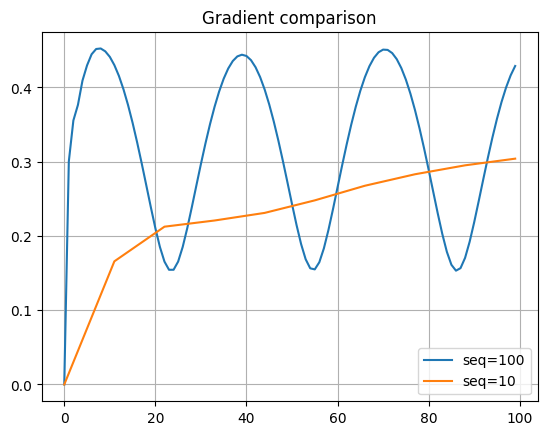

In [5]:
seq_length = 10
X, y = create_sequences(data, seq_length)

X = torch.FloatTensor(X)
y = torch.FloatTensor(y)

model = RNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

model.train()

out, _ = model.rnn(X)

grads_10 = []

for t in range(seq_length):
    optimizer.zero_grad()
    pred = model.fc(out[:, t, :])
    loss = criterion(pred, y)
    loss.backward(retain_graph=True)
    grads_10.append(model.rnn.weight_hh_l0.grad.norm().item())
    model.rnn.weight_hh_l0.grad = None

plt.plot(grads, label="seq=100")
plt.plot(np.linspace(0, 99, len(grads_10)), grads_10, label="seq=10")

plt.legend()
plt.grid()
plt.title("Gradient comparison")
plt.show()